<a href="https://colab.research.google.com/github/NischalGrg5555/AI-Level-6/blob/main/Worksheet_6_Nischal_Gurung.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nischal Gurung - Workshop 6

**Task 1**

Repeat all the task from worksheet - 5 but, try to improve the model from last week with same dataset.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import matplotlib.pyplot as plt
import random
import cv2
import numpy as np

In [3]:
# Define dataset paths
train_dir = "/content/drive/MyDrive/AI/Week 6/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI/Week 6/FruitinAmazon/test"

In [4]:
classes = sorted(os.listdir(train_dir))
classes = [cls for cls in classes if os.path.isdir(os.path.join(train_dir, cls))]

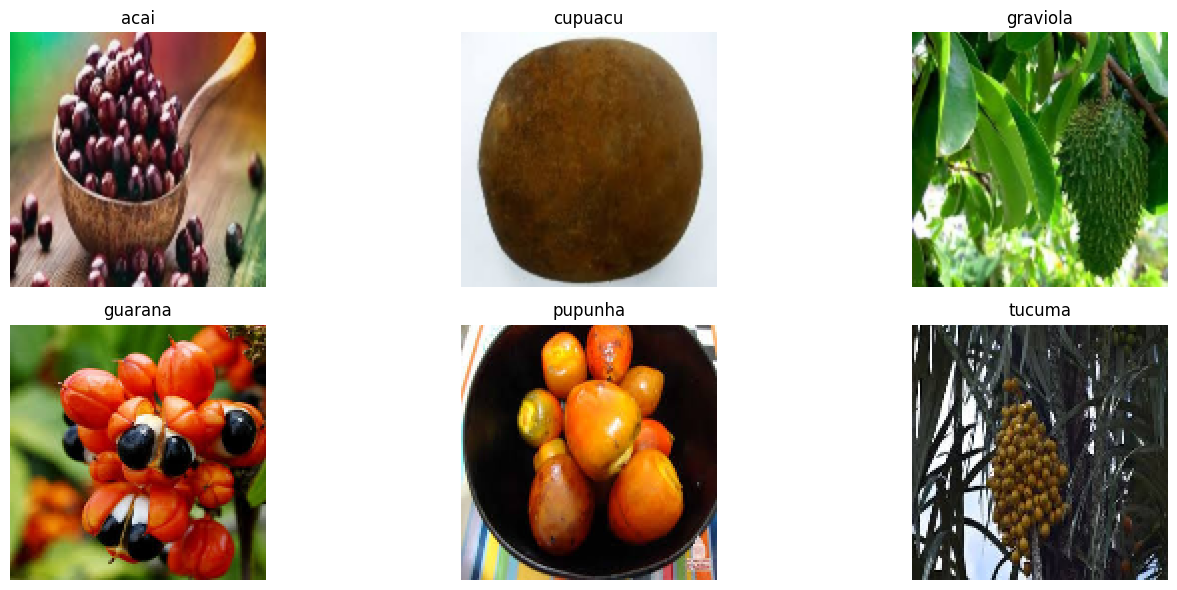

In [5]:
import os
import random
import cv2
import matplotlib.pyplot as plt

selected_images = []
labels = []

# Loop through each class and load a random image
for cls in classes:
    class_path = os.path.join(train_dir, cls)
    images = os.listdir(class_path)
    random.shuffle(images)
    random_image = images[0]
    img_path = os.path.join(class_path, random_image)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    img = cv2.resize(img, (128, 128))  # Resize image to (128, 128)
    selected_images.append(img)
    labels.append(cls)

# Set up the plot grid
fig, axes = plt.subplots(nrows=2, ncols=len(selected_images) // 2, figsize=(15, 6))
axes = axes.flatten()

# Display images in a grid
for i, img in enumerate(selected_images):
    axes[i].imshow(img)
    axes[i].set_title(labels[i])
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [6]:
from PIL import Image

corrupted_images = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            print(f"Removed corrupted image: {img_path}")
            corrupted_images.append(img_path)
            os.remove(img_path)

if not corrupted_images:
    print("No corrupted images found.")

No corrupted images found.


In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Set image size and batch size
img_height, img_width = 128, 128
batch_size = 32
input_shape = (img_height, img_width, 3)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomBrightness(0.2),
])


# Load training & validation set
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Get class count
class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [8]:
model = keras.Sequential([
    layers.Input(shape=input_shape),

    # Data Augmentation
    data_augmentation,

    # Rescaling
    layers.Rescaling(1./255),

    # Conv Block 1
    layers.Conv2D(32, 3, padding="same", activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Conv Block 2
    layers.Conv2D(64, 3, padding="same", activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Conv Block 3
    layers.Conv2D(128, 3, padding="same", activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Flatten and Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

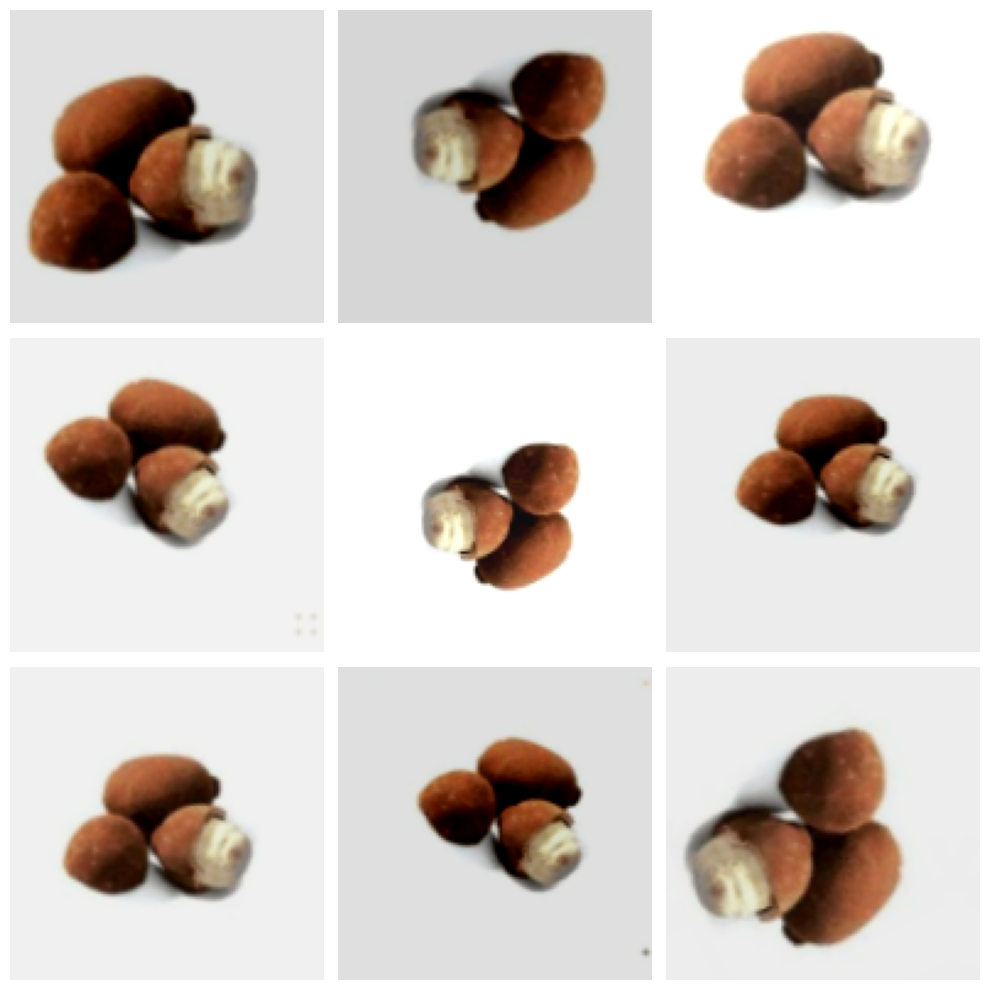

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.2500 - loss: 2.0939 - val_accuracy: 0.3889 - val_loss: 1.7251
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4306 - loss: 1.5479 - val_accuracy: 0.3333 - val_loss: 1.7098
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.4861 - loss: 1.3626 - val_accuracy: 0.3333 - val_loss: 1.7999
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5833 - loss: 1.1864 - val_accuracy: 0.2222 - val_loss: 1.9157
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.6111 - loss: 1.2463 - val_accuracy: 0.2222 - val_loss: 2.0050
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6111 - loss: 1.1894 - val_accuracy: 0.1111 - val_loss: 2.1339
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.5833 - loss: 1.1313 - val_accuracy: 0.1111 - val_loss: 2.3679
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.5278 - loss: 1.1867 - val_accuracy: 0.1111 - val_loss: 2.5218
Epoch 

In [12]:
# Get metrics from training
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           77

 Total params: 12,868,180 (49.09 MB)

 Trainable params: 4,289,158 (16.36 MB)

 Non-trainable params: 704 (2.75 KB)

 Optimizer params: 8,578,318 (32.72 MB)

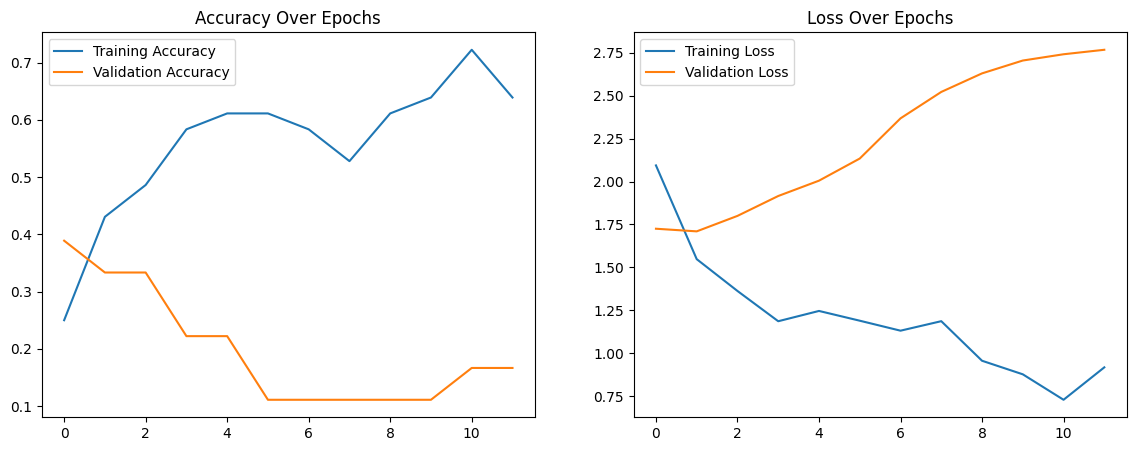

In [14]:
import matplotlib.pyplot as plt

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Over Epochs')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss Over Epochs')

plt.show()

In [15]:
val_loss, val_acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.3333 - loss: 1.7098
Validation Accuracy: 0.3333
Validation Loss: 1.7098


In [16]:
#load test ds for evaluation
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

class_names = test_ds.class_names

Found 30 files belonging to 6 classes.


In [17]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.2000 - loss: 1.7291

 Test Accuracy: 0.2000


In [18]:
from sklearn.metrics import classification_report

# True and predicted labels
y_true_test = []
y_pred_test = []

# Predict on test dataset
for images, labels in test_ds:
    preds = model.predict(images)
    y_true_test.extend(labels.numpy())
    y_pred_test.extend(np.argmax(preds, axis=1))

# Generate the classification report
print("\n Classification Report on Test Set:\n")
print(classification_report(y_true_test, y_pred_test, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step

 Classification Report on Test Set:

              precision    recall  f1-score   support

        acai       1.00      0.20      0.33         5
     cupuacu       0.00      0.00      0.00         5
    graviola       0.00      0.00      0.00         5
     guarana       0.20      1.00      0.33         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.20        30
   macro avg       0.20      0.20      0.11        30
weighted avg       0.20      0.20      0.11        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Task 2**

In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

In [20]:
# Define dataset paths
train_dir = "/content/drive/MyDrive/AI/Week 5/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI/Week 5/FruitinAmazon/test"

In [21]:
 img_height, img_width = 224, 224
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


In [22]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Freeze all layers to prevent them from training
for layer in base_model.layers:
    layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [23]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
predictions = layers.Dense(num_classes, activation='softmax')(x)

# Final model
model = keras.Model(inputs=base_model.input, outputs=predictions)

In [31]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 80s 23s/step - accuracy: 0.1667 - loss: 12.7648 - val_accuracy: 0.2222 - val_loss: 4.2133
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 69s 22s/step - accuracy: 0.2917 - loss: 6.1281 - val_accuracy: 0.2778 - val_loss: 3.8146
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 73s 18s/step - accuracy: 0.3056 - loss: 6.0424 - val_accuracy: 0.4444 - val_loss: 2.6978
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 92s 23s/step - accuracy: 0.4306 - loss: 4.0423 - val_accuracy: 0.6111 - val_loss: 1.9296
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 70s 23s/step - accuracy: 0.5694 - loss: 2.6477 - val_accuracy: 0.5556 - val_loss: 1.7520
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 66s 23s/step - accuracy: 0.6389 - loss: 1.9557 - val_accuracy: 0.6111 - val_loss: 1.8447
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 74s 19s/step - accuracy: 0.7361 - loss: 1.4894 - val_accuracy: 0.5556 - val_loss: 1.9424
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 90s 22s/step - accuracy: 0.7500 - loss: 1.4525 - val_accuracy: 0.5556 - val_loss

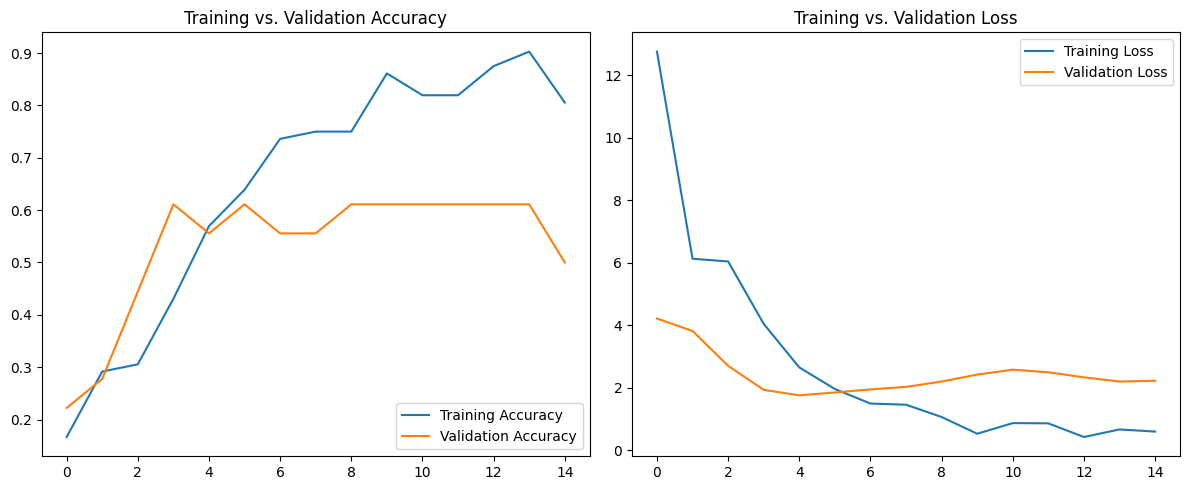

In [26]:
import matplotlib.pyplot as plt

# Extract data from history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# Plot
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training vs. Validation Accuracy')

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training vs. Validation Loss')

plt.tight_layout()
plt.show()

In [27]:
# Predict on validation set and print some results
inference_labels = []
inference_preds = []

for images, labels in val_ds:
    preds = model.predict(images)
    inference_labels.extend(labels.numpy())
    inference_preds.extend(np.argmax(preds, axis=1))

print("\n Inference Output (Validation Set):")
for i in range(10):  # Print 10 samples
    true_label = class_names[inference_labels[i]]
    pred_label = class_names[inference_preds[i]]
    print(f"True: {true_label:<10} | Predicted: {pred_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step

 Inference Output (Validation Set):
True: guarana    | Predicted: pupunha
True: guarana    | Predicted: cupuacu
True: tucuma     | Predicted: tucuma
True: pupunha    | Predicted: guarana
True: guarana    | Predicted: guarana
True: guarana    | Predicted: guarana
True: tucuma     | Predicted: pupunha
True: pupunha    | Predicted: tucuma
True: graviola   | Predicted: graviola
True: cupuacu    | Predicted: pupunha


In [28]:
class_names = train_ds.class_names

In [29]:
from sklearn.metrics import classification_report
import numpy as np

y_true_test = []
y_pred_test = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true_test.extend(labels.numpy())
    y_pred_test.extend(np.argmax(preds, axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step


In [30]:
print("\n Classification Report on Test Set:\n")
print(classification_report(y_true_test, y_pred_test, target_names=class_names))


 Classification Report on Test Set:

              precision    recall  f1-score   support

        acai       1.00      0.60      0.75         5
     cupuacu       0.71      1.00      0.83         5
    graviola       0.83      1.00      0.91         5
     guarana       1.00      0.60      0.75         5
     pupunha       0.50      0.20      0.29         5
      tucuma       0.44      0.80      0.57         5

    accuracy                           0.70        30
   macro avg       0.75      0.70      0.68        30
weighted avg       0.75      0.70      0.68        30



**Did the performance improved compared to training from scratch.**

The VGG16 transfer learning model did slightly better than the model trained from scratch. Even though both had similar accuracy (~17%), the VGG16 model was able to predict more than one class correctly. This shows that transfer learning helped the model understand the data better.